# Лабораторная работа
**Вариант 10, n = 45**

## 1. Загрузка данных

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv('variant_10_data.csv')
print(df.to_string(index=False))

 i       x       y
 1  2.0016  2.2764
 2  2.0525 -0.5495
 3  2.4741  1.4127
 4  2.6482 -0.1272
 5  2.8584  0.9206
 6  3.4765  0.1657
 7  3.5725 -0.1315
 8  3.7578 -1.8581
 9  3.9470 -2.5540
10  4.0205 -0.3421
11  4.1819 -0.8197
12  4.4176 -0.5606
13  5.0805 -0.4812
14  5.1735 -0.6394
15  5.2515 -2.9748
16  5.2617 -0.8575
17  5.5196 -1.3149
18  5.8274 -1.1604
19  5.8493 -1.5649
20  6.5956 -0.8225
21  6.7394 -2.6105
22  6.8201 -1.9404
23  7.0663 -2.1262
24  7.3654 -3.1121
25  7.4485 -2.4879
26  7.9157 -2.5422
27  8.0208 -2.3972
28  8.1675 -4.3492
29  8.2510 -5.0899
30  8.6131 -4.7360
31  8.8126 -2.6570
32  8.9616 -4.0206
33  9.1694 -6.2229
34  9.3062 -5.2113
35  9.7490 -5.3387
36  9.9138 -4.2151
37 10.1398 -4.4793
38 10.1726 -4.3817
39 10.5974 -5.5552
40 11.0031 -6.7192
41 11.1178 -6.2330
42 11.1553 -4.8272
43 11.6389 -7.5373
44 11.8551 -8.3722
45 12.1205 -6.2467


## 2. Диаграмма рассеяния

n = 45


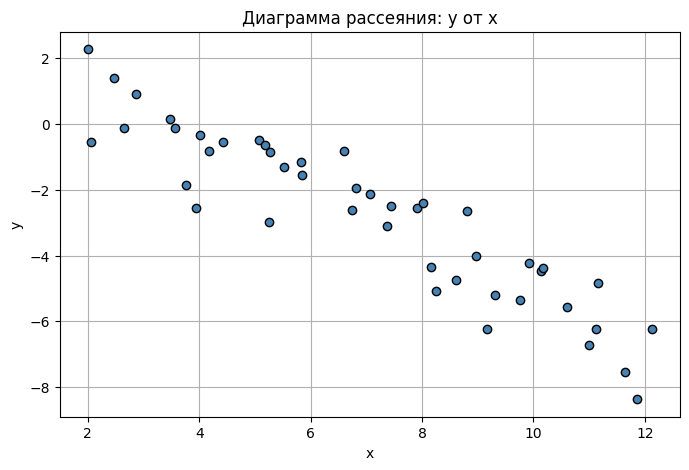

Вывод: по графику видна убывающая линейная зависимость - чем больше x, тем меньше y, зависимость отрицательная.


In [24]:
x = df['x'].values
y = df['y'].values
n = len(x)
print(f'n = {n}')

plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='steelblue', edgecolors='black', zorder=3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Диаграмма рассеяния: y от x')
plt.grid(True)
plt.show()

print('Вывод: по графику видна убывающая линейная зависимость - чем больше x, тем меньше y, зависимость отрицательная.')

## 3. Оценка коэффициентов регрессии

Формулы:

x_mean = (1/n) * sum(x_i)

y_mean = (1/n) * sum(y_i)

Sxx = sum((x_i - x_mean)^2)

Sxy = sum((x_i - x_mean) * (y_i - y_mean))

beta1_hat = Sxy / Sxx

beta0_hat = y_mean - beta1_hat * x_mean

In [25]:
x_mean = np.mean(x)
y_mean = np.mean(y)

print(f'x_mean = {x_mean:.4f}')
print(f'y_mean = {y_mean:.4f}')

Sxx = np.sum((x - x_mean)**2)
Sxy = np.sum((x - x_mean) * (y - y_mean))

print(f'\nSxx = sum((x_i - x_mean)^2) = {Sxx:.4f}')
print(f'Sxy = sum((x_i - x_mean)*(y_i - y_mean)) = {Sxy:.4f}')

beta1_hat = Sxy / Sxx
beta0_hat = y_mean - beta1_hat * x_mean

print(f'\nbeta1_hat = Sxy / Sxx = {Sxy:.4f} / {Sxx:.4f} = {beta1_hat:.4f}')
print(f'beta0_hat = y_mean - beta1_hat * x_mean = {y_mean:.4f} - ({beta1_hat:.4f})*{x_mean:.4f} = {beta0_hat:.4f}')
print(f'\nУравнение регрессии: y_hat = {beta0_hat:.4f} + ({beta1_hat:.4f}) * x')

x_mean = 7.0242
y_mean = -2.7865

Sxx = sum((x_i - x_mean)^2) = 387.1264
Sxy = sum((x_i - x_mean)*(y_i - y_mean)) = -301.1641

beta1_hat = Sxy / Sxx = -301.1641 / 387.1264 = -0.7779
beta0_hat = y_mean - beta1_hat * x_mean = -2.7865 - (-0.7779)*7.0242 = 2.6780

Уравнение регрессии: y_hat = 2.6780 + (-0.7779) * x


## 4. Прогнозные значения и остатки

y_hat_i = beta0_hat + beta1_hat * x_i

e_i = y_i - y_hat_i

In [26]:
y_hat = beta0_hat + beta1_hat * x
e = y - y_hat
e2 = e**2

table = pd.DataFrame({
    'i': df['i'],
    'x_i': x,
    'y_i': y,
    'y_hat_i': np.round(y_hat, 4),
    'e_i': np.round(e, 4),
    'e_i^2': np.round(e2, 4)
})

print(table.to_string(index=False))

 i     x_i     y_i  y_hat_i     e_i  e_i^2
 1  2.0016  2.2764   1.1208  1.1556 1.3354
 2  2.0525 -0.5495   1.0812 -1.6307 2.6593
 3  2.4741  1.4127   0.7532  0.6595 0.4349
 4  2.6482 -0.1272   0.6178 -0.7450 0.5550
 5  2.8584  0.9206   0.4543  0.4663 0.2175
 6  3.4765  0.1657  -0.0266  0.1923 0.0370
 7  3.5725 -0.1315  -0.1013 -0.0302 0.0009
 8  3.7578 -1.8581  -0.2454 -1.6127 2.6008
 9  3.9470 -2.5540  -0.3926 -2.1614 4.6717
10  4.0205 -0.3421  -0.4498  0.1077 0.0116
11  4.1819 -0.8197  -0.5753 -0.2444 0.0597
12  4.4176 -0.5606  -0.7587  0.1981 0.0392
13  5.0805 -0.4812  -1.2744  0.7932 0.6292
14  5.1735 -0.6394  -1.3467  0.7073 0.5003
15  5.2515 -2.9748  -1.4074 -1.5674 2.4567
16  5.2617 -0.8575  -1.4154  0.5579 0.3112
17  5.5196 -1.3149  -1.6160  0.3011 0.0907
18  5.8274 -1.1604  -1.8554  0.6950 0.4831
19  5.8493 -1.5649  -1.8725  0.3076 0.0946
20  6.5956 -0.8225  -2.4531  1.6306 2.6587
21  6.7394 -2.6105  -2.5649 -0.0456 0.0021
22  6.8201 -1.9404  -2.6277  0.6873 0.4724
23  7.0663 

## 5. Оценка дисперсии ошибки

RSS = sum(e_i^2)

s^2 = RSS / (n - 2)  - несмещённая оценка дисперсии

s = sqrt(s^2) - остаточное стандартное отклонение

In [27]:
RSS = np.sum(e2)
s2 = RSS / (n - 2)
s = np.sqrt(s2)

print(f'RSS = sum(e_i^2) = {RSS:.4f}')
print(f's^2 = RSS / (n-2) = {RSS:.4f} / {n-2} = {s2:.4f}')
print(f's = sqrt(s^2) = sqrt({s2:.4f}) = {s:.4f}')

# также считаем TSS и R^2 сразу
TSS = np.sum((y - y_mean)**2)
R2 = 1 - RSS / TSS
print(f'\nTSS = sum((y_i - y_mean)^2) = {TSS:.4f}')
print(f'R^2 = 1 - RSS/TSS = 1 - {RSS:.4f}/{TSS:.4f} = {R2:.4f}')

RSS = sum(e_i^2) = 41.3623
s^2 = RSS / (n-2) = 41.3623 / 43 = 0.9619
s = sqrt(s^2) = sqrt(0.9619) = 0.9808

TSS = sum((y_i - y_mean)^2) = 275.6522
R^2 = 1 - RSS/TSS = 1 - 41.3623/275.6522 = 0.8499


## 6. Стандартные ошибки коэффициентов

SE(beta1_hat) = s / sqrt(Sxx)

SE(beta0_hat) = s * sqrt(1/n + x_mean^2 / Sxx)

In [28]:
SE_beta1 = s / np.sqrt(Sxx)
SE_beta0 = s * np.sqrt(1/n + x_mean**2 / Sxx)

print(f'SE(beta1_hat) = s / sqrt(Sxx) = {s:.4f} / sqrt({Sxx:.4f}) = {s:.4f} / {np.sqrt(Sxx):.4f} = {SE_beta1:.4f}')
print(f'SE(beta0_hat) = s * sqrt(1/n + x_mean^2/Sxx)')
print(f'             = {s:.4f} * sqrt(1/{n} + {x_mean:.4f}^2 / {Sxx:.4f})')
print(f'             = {s:.4f} * sqrt({1/n:.6f} + {x_mean**2/Sxx:.6f})')
print(f'             = {s:.4f} * sqrt({1/n + x_mean**2/Sxx:.6f})')
print(f'             = {SE_beta0:.4f}')

SE(beta1_hat) = s / sqrt(Sxx) = 0.9808 / sqrt(387.1264) = 0.9808 / 19.6755 = 0.0498
SE(beta0_hat) = s * sqrt(1/n + x_mean^2/Sxx)
             = 0.9808 * sqrt(1/45 + 7.0242^2 / 387.1264)
             = 0.9808 * sqrt(0.022222 + 0.127450)
             = 0.9808 * sqrt(0.149672)
             = 0.3794


## 7. Доверительные интервалы для коэффициентов (95%)

alpha = 0.05

t_cr = t(1 - alpha/2; n-2) = t(0.975; 43)

ДИ для beta0: [beta0_hat - t_cr * SE(beta0_hat), beta0_hat + t_cr * SE(beta0_hat)]

ДИ для beta1: [beta1_hat - t_cr * SE(beta1_hat), beta1_hat + t_cr * SE(beta1_hat)]

In [29]:
alpha = 0.05
t_cr = stats.t.ppf(1 - alpha/2, df=n-2)
print(f't_cr = t(0.975; {n-2}) = {t_cr:.4f}')

CI_beta0_low = beta0_hat - t_cr * SE_beta0
CI_beta0_high = beta0_hat + t_cr * SE_beta0

CI_beta1_low = beta1_hat - t_cr * SE_beta1
CI_beta1_high = beta1_hat + t_cr * SE_beta1

print(f'\n95% ДИ для beta0:')
print(f'  beta0_hat +/- t_cr * SE(beta0_hat) = {beta0_hat:.4f} +/- {t_cr:.4f} * {SE_beta0:.4f}')
print(f'  = {beta0_hat:.4f} +/- {t_cr*SE_beta0:.4f}')
print(f'  => [{CI_beta0_low:.4f}, {CI_beta0_high:.4f}]')

print(f'\n95% ДИ для beta1:')
print(f'  beta1_hat +/- t_cr * SE(beta1_hat) = {beta1_hat:.4f} +/- {t_cr:.4f} * {SE_beta1:.4f}')
print(f'  = {beta1_hat:.4f} +/- {t_cr*SE_beta1:.4f}')
print(f'  => [{CI_beta1_low:.4f}, {CI_beta1_high:.4f}]')

if CI_beta1_low > 0 or CI_beta1_high < 0:
    print(f'\nВывод: 0 НЕ попадает в ДИ для beta1 => линейная зависимость статистически значима на уровне 5%.')
else:
    print(f'\nВывод: 0 попадает в ДИ для beta1 => линейная зависимость НЕ значима на уровне 5%')

t_cr = t(0.975; 43) = 2.0167

95% ДИ для beta0:
  beta0_hat +/- t_cr * SE(beta0_hat) = 2.6780 +/- 2.0167 * 0.3794
  = 2.6780 +/- 0.7652
  => [1.9128, 3.4432]

95% ДИ для beta1:
  beta1_hat +/- t_cr * SE(beta1_hat) = -0.7779 +/- 2.0167 * 0.0498
  = -0.7779 +/- 0.1005
  => [-0.8785, -0.6774]

Вывод: 0 НЕ попадает в ДИ для beta1 => линейная зависимость статистически значима на уровне 5%.


## 8. Доверительный интервал для средней функции регрессии E(Y|x)

Для каждого x0:

y_hat(x0) = beta0_hat + beta1_hat * x0

SE_y_hat(x0) = s * sqrt(1/n + (x0 - x_mean)^2 / Sxx)

95% ДИ: [y_hat(x0) - t_cr * SE_y_hat(x0),  y_hat(x0) + t_cr * SE_y_hat(x0)]

In [30]:
x0_grid = np.linspace(x.min(), x.max(), 200)

y_hat_grid = beta0_hat + beta1_hat * x0_grid
SE_y_hat_grid = s * np.sqrt(1/n + (x0_grid - x_mean)**2 / Sxx)

CI_low_grid = y_hat_grid - t_cr * SE_y_hat_grid
CI_high_grid = y_hat_grid + t_cr * SE_y_hat_grid

# значения на концах и в середине 
check_pts = [x.min(), x_mean, x.max()]
print('Значения ДИ для средней функции регрессии в контрольных точках:')
print(f'{"x0":>10} {"y_hat":>10} {"SE":>10} {"CI_low":>10} {"CI_high":>10}')
for xp in check_pts:
    yp = beta0_hat + beta1_hat * xp
    sep = s * np.sqrt(1/n + (xp - x_mean)**2 / Sxx)
    print(f'{xp:>10.4f} {yp:>10.4f} {sep:>10.4f} {yp - t_cr*sep:>10.4f} {yp + t_cr*sep:>10.4f}')

Значения ДИ для средней функции регрессии в контрольных точках:
        x0      y_hat         SE     CI_low    CI_high
    2.0016     1.1208     0.2899     0.5361     1.7055
    7.0242    -2.7865     0.1462    -3.0813    -2.4916
   12.1205    -6.7511     0.2931    -7.3423    -6.1600


## 9. Итоговый график

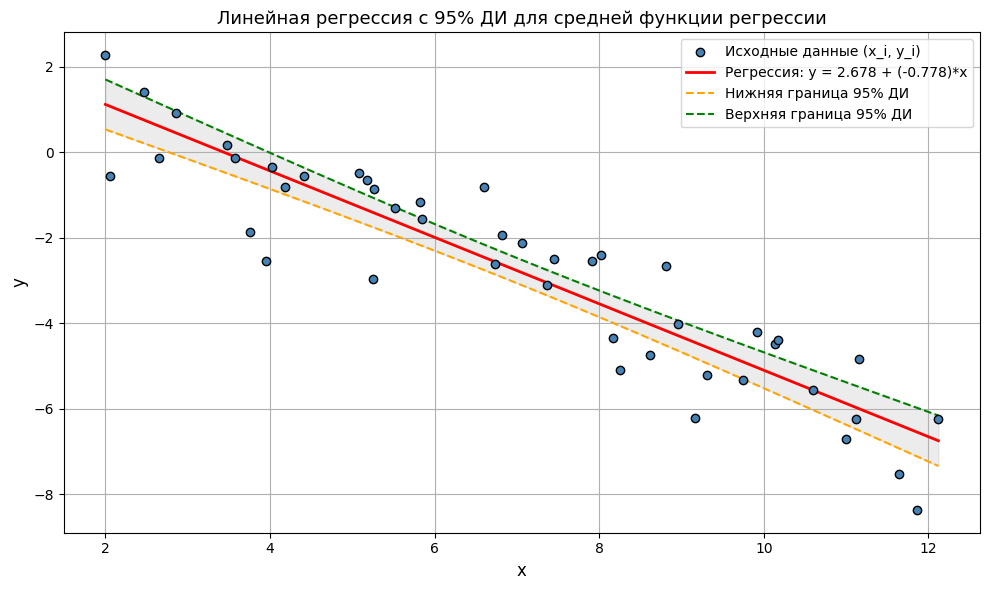

In [31]:
plt.figure(figsize=(10, 6))

plt.scatter(x, y, color='steelblue', edgecolors='black', zorder=3, label='Исходные данные (x_i, y_i)')
plt.plot(x0_grid, y_hat_grid, color='red', linewidth=2, label=f'Регрессия: y = {beta0_hat:.3f} + ({beta1_hat:.3f})*x')
plt.plot(x0_grid, CI_low_grid, color='orange', linewidth=1.5, linestyle='--', label='Нижняя граница 95% ДИ')
plt.plot(x0_grid, CI_high_grid, color='green', linewidth=1.5, linestyle='--', label='Верхняя граница 95% ДИ')
plt.fill_between(x0_grid, CI_low_grid, CI_high_grid, alpha=0.15, color='gray')

plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Линейная регрессия с 95% ДИ для средней функции регрессии', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

## 10. Выводы

In [32]:
print('Результаты:')
print(f'n = {n}')
print(f'x_mean = {x_mean:.4f},  y_mean = {y_mean:.4f}')
print(f'Sxx = {Sxx:.4f},  Sxy = {Sxy:.4f}')
print()
print(f'beta0_hat = {beta0_hat:.4f}')
print(f'beta1_hat = {beta1_hat:.4f}')
print(f'Уравнение: y_hat = {beta0_hat:.4f} + ({beta1_hat:.4f})*x')
print()
print(f'RSS = {RSS:.4f}')
print(f's^2 = {s2:.4f}')
print(f's = {s:.4f}')
print(f'R^2 = {R2:.4f}')
print()
print(f'SE(beta0_hat) = {SE_beta0:.4f}')
print(f'SE(beta1_hat) = {SE_beta1:.4f}')
print(f't_cr (df={n-2}, alpha=0.05) = {t_cr:.4f}')
print()
print(f'95% ДИ для beta0: [{CI_beta0_low:.4f}, {CI_beta0_high:.4f}]')
print(f'95% ДИ для beta1: [{CI_beta1_low:.4f}, {CI_beta1_high:.4f}]')
print()
print('Ответы на вопросы')
print(f'1. Уравнение регрессии: y_hat = {beta0_hat:.4f} + ({beta1_hat:.4f})*x')
print(f'2. Зависимость отрицательная (beta1_hat = {beta1_hat:.4f} < 0) — y убывает с ростом x')
print(f'3. 0 в ДИ для beta1 [{CI_beta1_low:.4f}, {CI_beta1_high:.4f}]: НЕТ => зависимость статистически значима')
print(f'4. Линейная зависимость статистически значима на уровне 5%')
print(f'5. ДИ наиболее узкий в точке x = x_mean = {x_mean:.4f} (середина диапазона x')
print(f'6. R^2 = {R2:.4f} => модель объясняет {R2*100:.1f}% изменчивости y. По графику точки лежат достаточно близко к прямой')

Результаты:
n = 45
x_mean = 7.0242,  y_mean = -2.7865
Sxx = 387.1264,  Sxy = -301.1641

beta0_hat = 2.6780
beta1_hat = -0.7779
Уравнение: y_hat = 2.6780 + (-0.7779)*x

RSS = 41.3623
s^2 = 0.9619
s = 0.9808
R^2 = 0.8499

SE(beta0_hat) = 0.3794
SE(beta1_hat) = 0.0498
t_cr (df=43, alpha=0.05) = 2.0167

95% ДИ для beta0: [1.9128, 3.4432]
95% ДИ для beta1: [-0.8785, -0.6774]

Ответы на вопросы
1. Уравнение регрессии: y_hat = 2.6780 + (-0.7779)*x
2. Зависимость отрицательная (beta1_hat = -0.7779 < 0) — y убывает с ростом x
3. 0 в ДИ для beta1 [-0.8785, -0.6774]: НЕТ => зависимость статистически значима
4. Линейная зависимость статистически значима на уровне 5%
5. ДИ наиболее узкий в точке x = x_mean = 7.0242 (середина диапазона x
6. R^2 = 0.8499 => модель объясняет 85.0% изменчивости y. По графику точки лежат достаточно близко к прямой
